<a href="https://colab.research.google.com/github/varshamqa/AutomateBrowserSerVSC-M1/blob/master/AI_ML_Lasso%26Ridge_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv('/content/HousingL&R.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


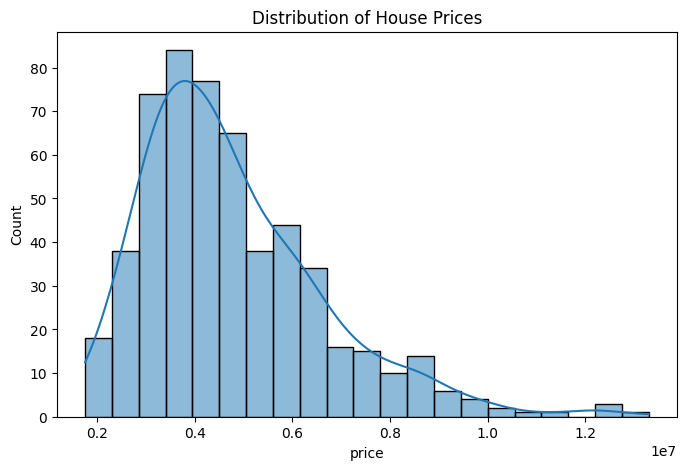

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(data['price'], kde=True)

plt.title("Distribution of House Prices")
plt.show()

In [7]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    data[col] = data[col].map({'yes':1,'no':0})

In [12]:
data = pd.get_dummies(
    data,
    columns=['furnishingstatus'],
    drop_first=True
)

In [13]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [14]:
data.shape

(545, 14)

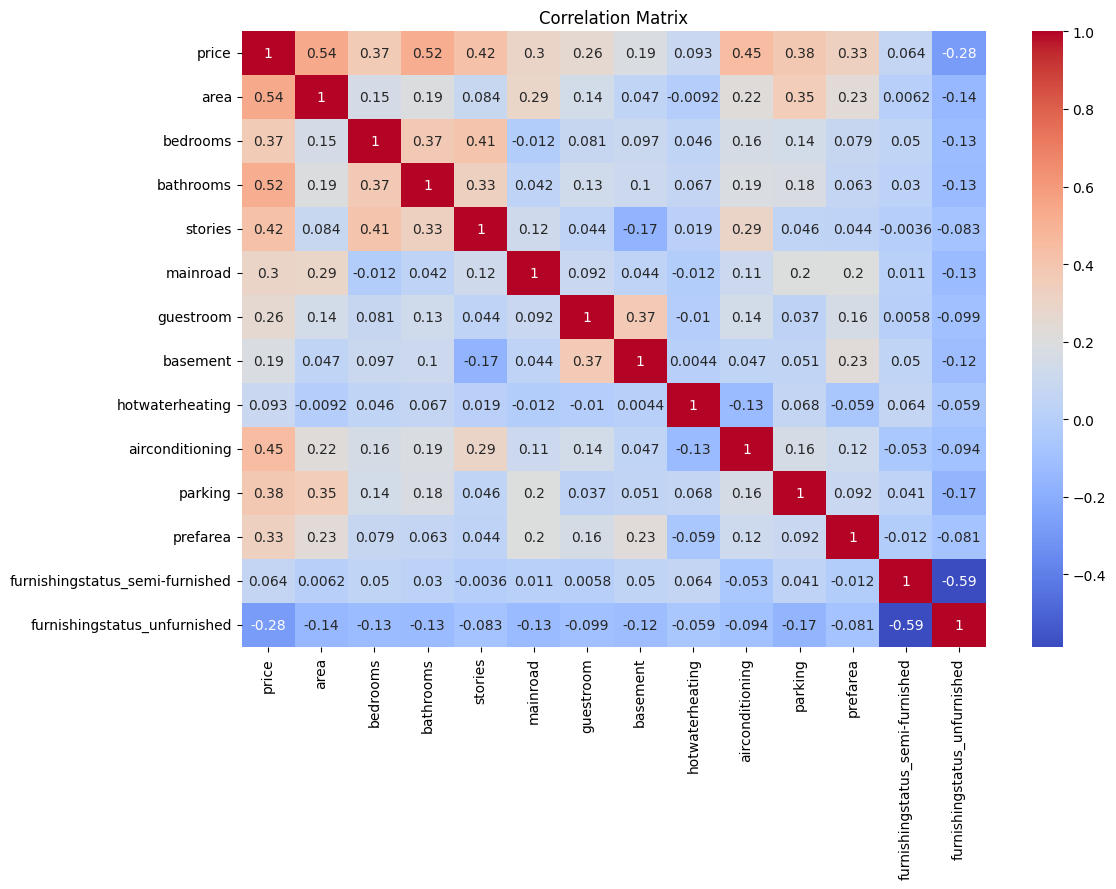

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [17]:
X = data.drop('price', axis=1)

y = data['price']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [21]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

Ridge()

In [22]:
ridge_pred = ridge.predict(X_test_scaled)

In [23]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("RIDGE REGRESSION RESULTS")
print("-"*40)

print("MAE  :", ridge_mae)
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2   :", ridge_r2)

RIDGE REGRESSION RESULTS
----------------------------------------
MAE  : 969857.9028478259
MSE  : 1754839327446.8074
RMSE : 1324703.4866138187
R2   : 0.6528212603810125


In [24]:
lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

Lasso()

In [25]:
lasso_pred = lasso.predict(X_test_scaled)

In [26]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, lasso_pred)

print("LASSO REGRESSION RESULTS")
print("-"*40)

print("MAE  :", lasso_mae)
print("MSE  :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R2   :", lasso_r2)

LASSO REGRESSION RESULTS
----------------------------------------
MAE  : 970043.4096094929
MSE  : 1754319994568.702
RMSE : 1324507.4535723466
R2   : 0.6529240055903563


In [27]:
coef_df = pd.DataFrame({

    "Feature":X.columns,

    "Ridge Coefficient":ridge.coef_,

    "Lasso Coefficient":lasso.coef_

})

coef_df

,Feature,Ridge Coefficient,Lasso Coefficient
0,area,518507.038230,519552.201607
1,bedrooms,58203.887057,57349.250380
2,bathrooms,520891.303462,521878.748411
3,stories,348503.409610,349250.977368
4,mainroad,128787.602807,128498.266610
5,guestroom,89134.877634,88768.293647
6,basement,186543.418912,187067.247872
7,hotwaterheating,149497.585709,149861.682004
8,airconditioning,364798.715170,365157.142484
9,parking,192163.570045,192005.648967


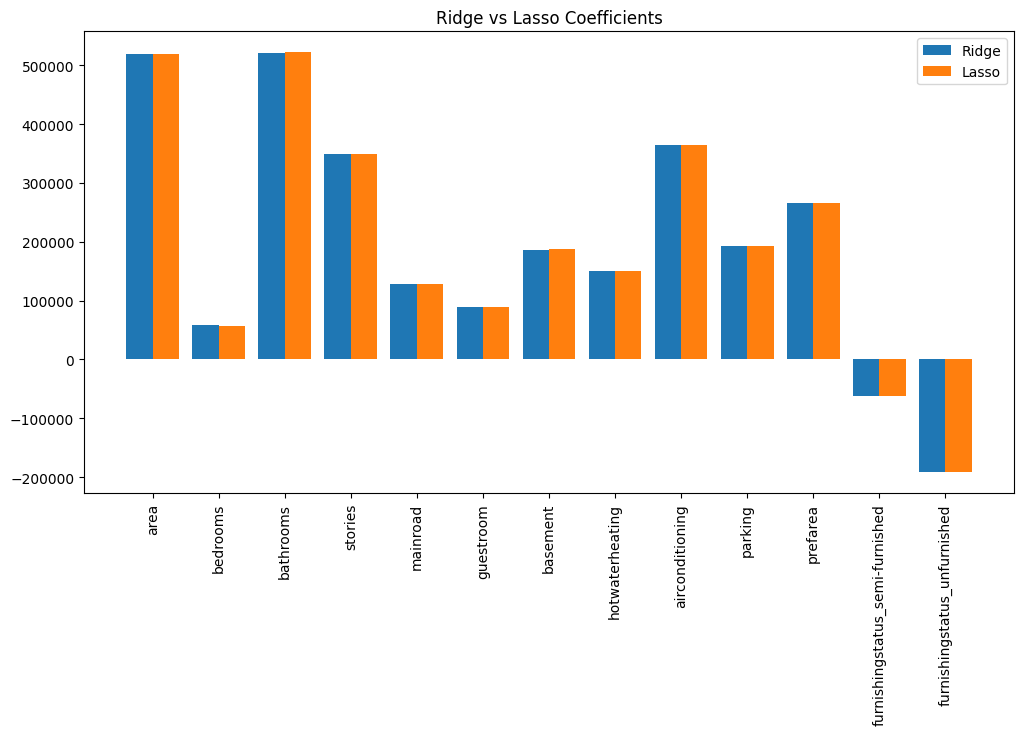

In [28]:
plt.figure(figsize=(12,6))

x = np.arange(len(X.columns))

plt.bar(
    x - 0.2,
    ridge.coef_,
    width=0.4,
    label="Ridge"
)

plt.bar(
    x + 0.2,
    lasso.coef_,
    width=0.4,
    label="Lasso"
)

plt.xticks(x, X.columns, rotation=90)

plt.legend()

plt.title("Ridge vs Lasso Coefficients")

plt.show()

In [29]:
alphas = [0.01,0.1,1,10,100,1000]

ridge_scores = []

for alpha in alphas:

    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_scaled,y_train)

    pred = ridge.predict(X_test_scaled)

    score = r2_score(y_test,pred)

    ridge_scores.append(score)

pd.DataFrame({
    "Alpha":alphas,
    "R2 Score":ridge_scores
})

,Alpha,R2 Score
0,0.01,0.652923
1,0.10,0.652914
2,1.00,0.652821
3,10.00,0.651785
4,100.00,0.634800
5,1000.00,0.436186


In [30]:
alphas = [0.01,0.1,1,10,100,1000]

lasso_scores = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha)

    lasso.fit(X_train_scaled,y_train)

    pred = lasso.predict(X_test_scaled)

    score = r2_score(y_test,pred)

    lasso_scores.append(score)

pd.DataFrame({
    "Alpha":alphas,
    "R2 Score":lasso_scores
})

,Alpha,R2 Score
0,0.01,0.652924
1,0.10,0.652924
2,1.00,0.652924
3,10.00,0.652922
4,100.00,0.652898
5,1000.00,0.652664
